# GEO-PYTHON: Final Assignment 
### _by Juan Zotes_

### 1. Read in the provided data file using pandas and convert missing data to NA values.
#### Data file characteristics:
Daily temperature data from Sodankylä (Finland) from January 1908 to October 2020.

In [35]:
import pandas as pd

# File path
fp = "2315676.txt"

# Read data
data = pd.read_csv(
    fp,
    sep = r"\s+", # Columns are separated by one or more whitespace characters (spaces or tabs)
    skiprows = [1], # Skip second row (----)
    na_values = ["-9999"] # Convert no_data values (-9999) into NaN
)

In [36]:
# Check first rows of the data
data.head()

,STATION,STATION_NAME,DATE,TAVG,TMAX,TMIN
0,GHCND:FI000007501,SODANKYLA-AWS-FI,19080101,NaN,2.0,-37.0
1,GHCND:FI000007501,SODANKYLA-AWS-FI,19080102,NaN,6.0,-26.0
2,GHCND:FI000007501,SODANKYLA-AWS-FI,19080103,NaN,7.0,-27.0
3,GHCND:FI000007501,SODANKYLA-AWS-FI,19080104,NaN,-3.0,-27.0
4,GHCND:FI000007501,SODANKYLA-AWS-FI,19080105,NaN,4.0,-36.0


In [37]:
# Delete unnecessary columns: STATION and STATION_NAME
data = data.drop(columns=["STATION", "STATION_NAME"])

In [38]:
# Check last rows of the data
data.tail()

,DATE,TAVG,TMAX,TMIN
41060,20201003,47.0,51.0,NaN
41061,20201004,43.0,47.0,37.0
41062,20201005,42.0,NaN,37.0
41063,20201006,45.0,46.0,43.0
41064,20201007,47.0,50.0,44.0


### 2. Fill in the missing values in the TAVG column with your estimates of the average daily temperature as noted above in the data section. You can then drop any average daily temperatures that are still missing.
There are many missing values in the TAVG column.
For days where the TAVG values are missing, calculate an estimate of the average daily temperature by averaging the TMAX and TMIN values. You may want to do this in a new column. Note don't replace the existing TAVG values with your estimates!

#### Create a new column with TAVG values and then averaging TMAX&TMIN values

In [39]:
# Create a new column copying the original TAVG values
data["TAVG_Fahr"] = data["TAVG"]

#Identify NaN rows
mask = data["TAVG_Fahr"].isna()

# Fill missing TAVG values with average temp as the mean of TMAX and TMIN 
data.loc[mask, "TAVG_Fahr"] = (
    data.loc[mask, "TMAX"] + data.loc[mask, "TMIN"]
) / 2

In [40]:
data.head(10)

,DATE,TAVG,TMAX,TMIN,TAVG_Fahr
0,19080101,NaN,2.0,-37.0,-17.5
1,19080102,NaN,6.0,-26.0,-10.0
2,19080103,NaN,7.0,-27.0,-10.0
3,19080104,NaN,-3.0,-27.0,-15.0
4,19080105,NaN,4.0,-36.0,-16.0
5,19080106,NaN,7.0,-1.0,3.0
6,19080107,NaN,8.0,-3.0,2.5
7,19080108,NaN,3.0,-9.0,-3.0
8,19080109,NaN,1.0,-25.0,-12.0
9,19080110,NaN,-10.0,-32.0,-21.0


In [41]:
data.tail()

,DATE,TAVG,TMAX,TMIN,TAVG_Fahr
41060,20201003,47.0,51.0,NaN,47.0
41061,20201004,43.0,47.0,37.0,43.0
41062,20201005,42.0,NaN,37.0,42.0
41063,20201006,45.0,46.0,43.0,45.0
41064,20201007,47.0,50.0,44.0,47.0


In [42]:
# Missing values check
data.isna().sum()

DATE             0
TAVG         19843
TMAX           769
TMIN          1946
TAVG_Fahr      183
dtype: int64

#### Drop rows containing missing values in the TAVG_Fahr column

In [43]:
data = data.dropna(subset=["TAVG_Fahr"])

In [44]:
# Missing values check
data.isna().sum()

DATE             0
TAVG         19660
TMAX           676
TMIN          1856
TAVG_Fahr        0
dtype: int64

### 3. Define and use a function to convert temperatures in Fahrenheit to Celsius.

In [45]:
"""
Convert temperature from Fahrenheit to Celsius.
    Parameter:
        temp_fahrenheit (float): temperature in °F
    Returns:
        float: temperature converted to °C
"""
# Define the function
def fahr_to_celsius(temp_fahr):
    return (temp_fahr - 32) / 1.8

In [46]:
# Apply the function to the TAVG_Fahr column and creat a new one.
data["TAVG_Celsius"] = fahr_to_celsius(data["TAVG_Fahr"])

In [47]:
# Check first rows
data.head(10)

,DATE,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius
0,19080101,NaN,2.0,-37.0,-17.5,-27.500000
1,19080102,NaN,6.0,-26.0,-10.0,-23.333333
2,19080103,NaN,7.0,-27.0,-10.0,-23.333333
3,19080104,NaN,-3.0,-27.0,-15.0,-26.111111
4,19080105,NaN,4.0,-36.0,-16.0,-26.666667
5,19080106,NaN,7.0,-1.0,3.0,-16.111111
6,19080107,NaN,8.0,-3.0,2.5,-16.388889
7,19080108,NaN,3.0,-9.0,-3.0,-19.444444
8,19080109,NaN,1.0,-25.0,-12.0,-24.444444
9,19080110,NaN,-10.0,-32.0,-21.0,-29.444444


### 4. Calculate seasonal average temperatures for each season in every year (e.g., Winter 1909, Spring 1909, Summer 1909, ...)


#### Convert DATE YRMODA into date time

In [48]:
data["DATE"] = pd.to_datetime(data["DATE"], format = "%Y%m%d")

In [49]:
data.tail()

,DATE,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius
41060,2020-10-03,47.0,51.0,NaN,47.0,8.333333
41061,2020-10-04,43.0,47.0,37.0,43.0,6.111111
41062,2020-10-05,42.0,NaN,37.0,42.0,5.555556
41063,2020-10-06,45.0,46.0,43.0,45.0,7.222222
41064,2020-10-07,47.0,50.0,44.0,47.0,8.333333


#### Calculate seasonal average temperature in every year

In [50]:
# Set date column as index
data = data.set_index("DATE")

In [51]:
data.head()

,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius
DATE,,,,,
1908-01-01,NaN,2.0,-37.0,-17.5,-27.500000
1908-01-02,NaN,6.0,-26.0,-10.0,-23.333333
1908-01-03,NaN,7.0,-27.0,-10.0,-23.333333
1908-01-04,NaN,-3.0,-27.0,-15.0,-26.111111
1908-01-05,NaN,4.0,-36.0,-16.0,-26.666667


In [52]:
# Extract year and month from datetime index
data["year"] = data.index.year
data["month"] = data.index.month

In [53]:
data.tail()

,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius,year,month
DATE,,,,,,,
2020-10-03,47.0,51.0,NaN,47.0,8.333333,2020,10
2020-10-04,43.0,47.0,37.0,43.0,6.111111,2020,10
2020-10-05,42.0,NaN,37.0,42.0,5.555556,2020,10
2020-10-06,45.0,46.0,43.0,45.0,7.222222,2020,10
2020-10-07,47.0,50.0,44.0,47.0,8.333333,2020,10


In [54]:
# Define seasons based on month
def assign_season(month): 
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Create Season Column
data["season"] = data["month"].apply(assign_season)

In [55]:
data.head()

,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius,year,month,season
DATE,,,,,,,,
1908-01-01,NaN,2.0,-37.0,-17.5,-27.500000,1908,1,Winter
1908-01-02,NaN,6.0,-26.0,-10.0,-23.333333,1908,1,Winter
1908-01-03,NaN,7.0,-27.0,-10.0,-23.333333,1908,1,Winter
1908-01-04,NaN,-3.0,-27.0,-15.0,-26.111111,1908,1,Winter
1908-01-05,NaN,4.0,-36.0,-16.0,-26.666667,1908,1,Winter


In [56]:
data.tail()

,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius,year,month,season
DATE,,,,,,,,
2020-10-03,47.0,51.0,NaN,47.0,8.333333,2020,10,Autumn
2020-10-04,43.0,47.0,37.0,43.0,6.111111,2020,10,Autumn
2020-10-05,42.0,NaN,37.0,42.0,5.555556,2020,10,Autumn
2020-10-06,45.0,46.0,43.0,45.0,7.222222,2020,10,Autumn
2020-10-07,47.0,50.0,44.0,47.0,8.333333,2020,10,Autumn


#### Seasonal definition

Climatological seasons are defined as continuous three-month periods.
For this reason, winter spans December, January, and February.

December is assigned to the following year so that each winter season
is treated as a single continuous period (e.g., Winter 1909 includes
December 1908, January 1909, and February 1909).


In [57]:
# Adjust year for December so that Winter spans Dec-Feb correctly
data["season_year"] = data["year"]
data.loc[data["month"] == 12, "season_year"] +=1

In [58]:
data.tail()

,TAVG,TMAX,TMIN,TAVG_Fahr,TAVG_Celsius,year,month,season,season_year
DATE,,,,,,,,,
2020-10-03,47.0,51.0,NaN,47.0,8.333333,2020,10,Autumn,2020
2020-10-04,43.0,47.0,37.0,43.0,6.111111,2020,10,Autumn,2020
2020-10-05,42.0,NaN,37.0,42.0,5.555556,2020,10,Autumn,2020
2020-10-06,45.0,46.0,43.0,45.0,7.222222,2020,10,Autumn,2020
2020-10-07,47.0,50.0,44.0,47.0,8.333333,2020,10,Autumn,2020


#### Create a new dataframe with the seasonal mean temperatures for each year 

In [59]:
# Calculate seasonal mean temperatures for each year
seasonal_temps = (
    data
    .groupby(["season_year", "season"])["TAVG_Celsius"]
    .mean()
    .reset_index()
)

In [60]:
seasonal_temps.head(12)

,season_year,season,TAVG_Celsius
0,1908,Autumn,-1.859217
1,1908,Spring,-2.346743
2,1908,Summer,11.425926
3,1908,Winter,-14.781746
4,1909,Autumn,-0.155827
5,1909,Spring,-5.487654
6,1909,Summer,11.814614
7,1909,Winter,-10.106589
8,1910,Autumn,-1.742063
9,1910,Spring,-0.122549


### 5. Calculate seasonal average temperatures for the reference period 1951-1980 (e.g., 4 values in total, one for each season)

In [61]:
# Select period
reference_period = seasonal_temps[
    (seasonal_temps["season_year"] >= 1951)
    &
    (seasonal_temps["season_year"] <= 1980)
]

In [62]:
# Calculate seasonal average values for the reference period
seasonal_temps_1951_1980 = (
    reference_period
    .groupby("season")["TAVG_Celsius"]
    .mean()
    .reset_index()
)

In [63]:
seasonal_temps_1951_1980.head()

,season,TAVG_Celsius
0,Autumn,-0.816010
1,Spring,-2.338516
2,Summer,12.400262
3,Winter,-13.474456


### 6. Calculate seasonal temperature anomalies for each year
Seasonal temperature anomalies are calculated as the difference between the seasonal mean temperature of each year and the corresponding seasonal mean temperature of the 1951–1980 reference period.

This approach follows the standard climatological definition of temperature anomalies.

__Anomaly(season, year) =
SeasonalMean(season, year) − ReferenceMean(season, 1951–1980)__

In [64]:
# Merge seasonal mean temperatures with reference period values
# This aligns each seasonal value with its corresponding reference mean
seasonal_anomalies = seasonal_temps.merge(
    seasonal_temps_1951_1980,
    on="season",
    suffixes=("", "_ref")
)

In [65]:
seasonal_anomalies

,season_year,season,TAVG_Celsius,TAVG_Celsius_ref
0,1908,Autumn,-1.859217,-0.816010
1,1908,Spring,-2.346743,-2.338516
2,1908,Summer,11.425926,12.400262
3,1908,Winter,-14.781746,-13.474456
4,1909,Autumn,-0.155827,-0.816010
...,...,...,...,...
447,2019,Winter,-12.370370,-13.474456
448,2020,Autumn,7.717718,-0.816010
449,2020,Spring,-0.827295,-2.338516
450,2020,Summer,14.438339,12.400262


In [66]:
# Calculate seasonal temperature anomalies
# An anomaly is defined as the difference between the seasonal mean
# temperature of a given year and the reference period mean
seasonal_anomalies["anomaly"] = (
    seasonal_anomalies["TAVG_Celsius"]
    - seasonal_anomalies["TAVG_Celsius_ref"]
)

In [67]:
seasonal_anomalies

,season_year,season,TAVG_Celsius,TAVG_Celsius_ref,anomaly
0,1908,Autumn,-1.859217,-0.816010,-1.043207
1,1908,Spring,-2.346743,-2.338516,-0.008227
2,1908,Summer,11.425926,12.400262,-0.974336
3,1908,Winter,-14.781746,-13.474456,-1.307290
4,1909,Autumn,-0.155827,-0.816010,0.660183
...,...,...,...,...,...
447,2019,Winter,-12.370370,-13.474456,1.104086
448,2020,Autumn,7.717718,-0.816010,8.533728
449,2020,Spring,-0.827295,-2.338516,1.511221
450,2020,Summer,14.438339,12.400262,2.038078


### 7. Plot the data as shown in the example above
Your task is to create a four-panel plot showing the seasonal temperature anomalies for winter, spring, summer, and autumn for the years 1909-2019. A template for how the final plot should look can be found below.

In [68]:
import matplotlib.pyplot as plt

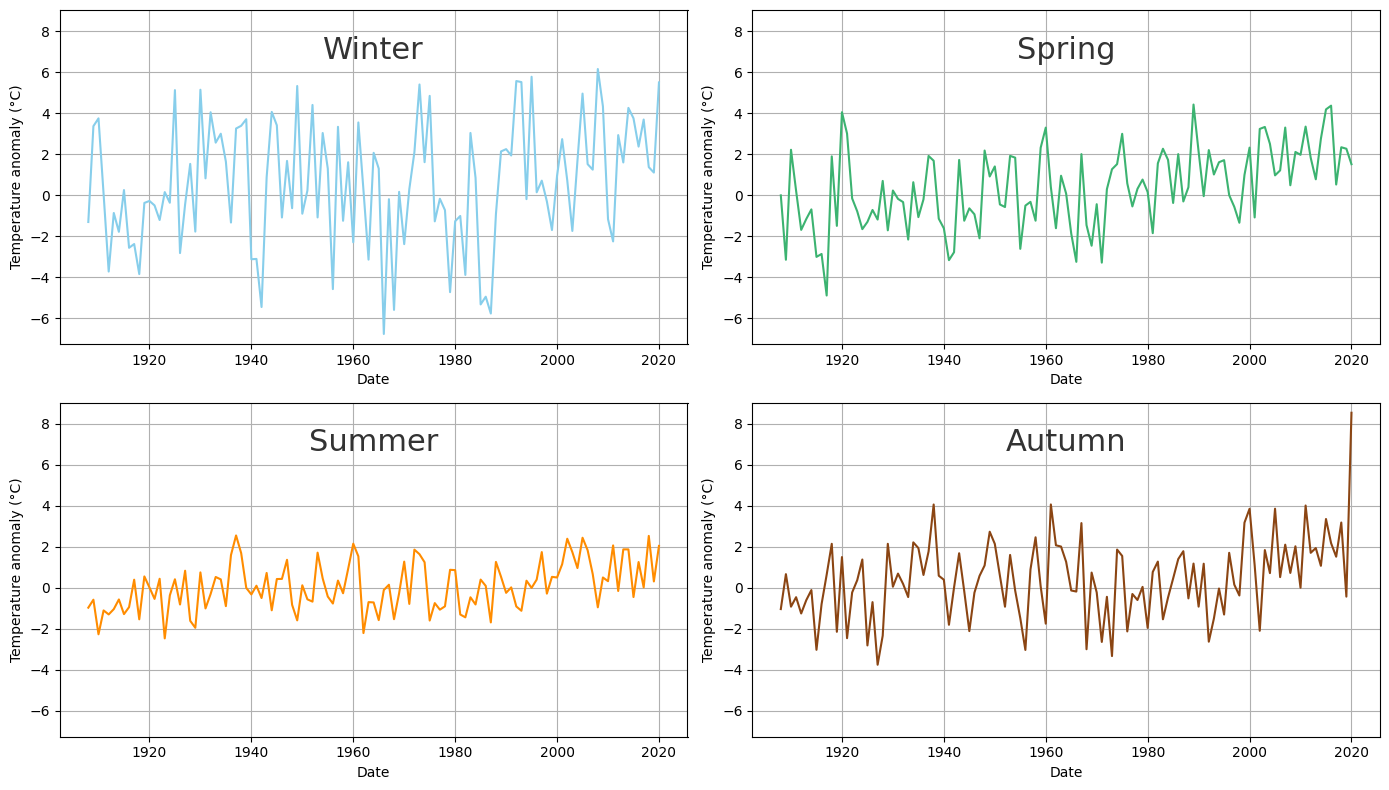

In [94]:
# Select data for each season
winter = seasonal_anomalies[seasonal_anomalies["season"] == "Winter"]
spring = seasonal_anomalies[seasonal_anomalies["season"] == "Spring"]
summer = seasonal_anomalies[seasonal_anomalies["season"] == "Summer"]
autumn = seasonal_anomalies[seasonal_anomalies["season"] == "Autumn"]

# Create a 2x2 figure layout
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Assign subplot axes for clarity
ax11, ax12 = axs[0]
ax21, ax22 = axs[1]

# Define common y-axis limits for all subplots
min_temp = seasonal_anomalies["anomaly"].min() - 0.5
max_temp = seasonal_anomalies["anomaly"].max() + 0.5

# Plot seasonal temperature anomalies for each season
ax11.plot(winter["season_year"], winter["anomaly"], c="skyblue", lw=1.5)
ax12.plot(spring["season_year"], spring["anomaly"], c="mediumseagreen", lw=1.5)
ax21.plot(summer["season_year"], summer["anomaly"], c="darkorange", lw=1.5)
ax22.plot(autumn["season_year"], autumn["anomaly"], c="saddlebrown", lw=1.5)

# Add large season labels in the center of each subplot
ax11.text(0.5, 0.88, "Winter", transform=ax11.transAxes,
          fontsize=22, ha="center", va="center", alpha=0.8)

ax12.text(0.5, 0.88, "Spring", transform=ax12.transAxes,
          fontsize=22, ha="center", va="center", alpha=0.8)

ax21.text(0.5, 0.88, "Summer", transform=ax21.transAxes,
          fontsize=22, ha="center", va="center", alpha=0.8)

ax22.text(0.5, 0.88, "Autumn", transform=ax22.transAxes,
          fontsize=22, ha="center", va="center", alpha=0.8)

# Set axis labels, limits, and grid for each subplot
for ax in axs.flat:
    ax.set_ylim(min_temp, max_temp)
    ax.set_xlabel("Date")
    ax.set_ylabel("Temperature anomaly (°C)")
    ax.grid(True)

# Adjust layout to avoid overlapping elements
plt.tight_layout()

# Save the figure to file
plt.savefig("seasonal_temperature_anomalies.png", dpi=300, bbox_inches="tight")

# Display the final figure
plt.show()
